<h1 style="text-align:center; color:#FFFF33;"><strong>NYC Taxi Trip EDA</strong></h1>


**Name:** Grandhi Akshay  
**Email:** [akshaygrandhi123@gmail.com](mailto:akshaygrandhi123@gmail.com)  
**Github Repo:** [https://github.com/akshaygrandhi123/Fractal_EDA_Preboarding](https://github.com/akshaygrandhi123/Fractal_EDA_Preboarding)


<h1 style="text-align:Left;"><strong>Data Understanding</strong></h1>

###  Summary:

- Loaded the dataset and displayed structure using .info(), .head() and .decribe()
- Explored shape, column names and data types
- Checked for null values in the dataset (There are no null values in this dataset upon checking - Good thing)
- Examined unique value counts and distributions for categorical features
- Identified trips with zero passengers and trips with duration less than 30secs (trip < 30sec is either an outlier or wrong entry or cancelled trip because trips on taxi can't be less than half a minute)
- Histogram of trip durations and analysed mode of the trip duration and percentage of trips with less than 60 mins duration from full dataset
- Identified outliers using speed in Km/min calculation

###  Description of all the variables/features available in the dataset (Given)

1. **id:** a unique identifier for each trip (Primary Key)
2. **vendor_id:** a code indicating the provider associated with the trip record (1/ or 2)
3. **pickup_datetime:** date and time when the meter was engaged  
4. **dropoff_datetime:** date and time when the meter was disengaged  
5. **passenger_count:** the number of passengers in the vehicle (driver entered value)
6. **pickup_longitude:** the longitude where the meter was engaged
7. **pickup_latitude:** the latitude where the meter was engaged
8. **dropoff_longitude:** the longitude where the meter was disengaged
9. **dropoff_latitude:** the latitude where the meter was disengaged
1. **store_and_fwd_flag:** This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y=store and forward; N=not a store and forward trip)
2. **trip_duration:** (target) duration of the trip in seconds

In [66]:
# install libraries incase not installed
!pip install geopy
!pip install plotly
!pip install haversine
!pip install ydata-profiling

In [67]:
import pandas as pd
import numpy as np
import time
import calendar
import matplotlib.pyplot as plt # Visualization
%matplotlib inline
import seaborn as sns
import plotly.express as px # Geolocation and Mapping
from geopy.geocoders import Nominatim 
from haversine import haversine, Unit
from ydata_profiling import ProfileReport # Pandas Profiling Report (automatic generation of EDA)


In [68]:
df = pd.read_csv("nyc_taxi_trip_duration.csv") # Load the dataset

In [69]:
df.head() # Return first 5 rows of the dataset

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [70]:
df.tail() # Return last 5 rows of the dataset

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
729317,id3905982,2,2016-05-21 13:29:38,2016-05-21 13:34:34,2,-73.965919,40.789780,-73.952637,40.789181,N,296
729318,id0102861,1,2016-02-22 00:43:11,2016-02-22 00:48:26,1,-73.996666,40.737434,-74.001320,40.731911,N,315
729319,id0439699,1,2016-04-15 18:56:48,2016-04-15 19:08:01,1,-73.997849,40.761696,-74.001488,40.741207,N,673
729320,id2078912,1,2016-06-19 09:50:47,2016-06-19 09:58:14,1,-74.006706,40.708244,-74.013550,40.713814,N,447
729321,id1053441,2,2016-01-01 17:24:16,2016-01-01 17:44:40,4,-74.003342,40.743839,-73.945847,40.712841,N,1224


In [71]:
df.shape # Return shape of the dataset

(729322, 11)

The given dataset has 729322 rows and 11 columns before data cleaning. 

In [72]:
df.columns # Return columns of the dataset

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [73]:
df.dtypes # Return data types of the columns

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

In [74]:
df.info() # Return information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [75]:
df.describe() # Return summary statistics of the dataset

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712234,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


1. Dataset Overview -  Contains **729,322** valid entries across all columns.
2. Vendor ID -  Only two unique vendors (1 and 2) with a almost balanced share (mean ≈ 1.53).
3. Passenger Count  
   * Average passengers per trip: **1.66** ~ 1/2 passengers
   * Min records show **0 passengers**, which is not possible or invalid so need to be removed later.
   * Maximum count of **9 passengers**, which is only possible for large vehicles.
4. Pickup and dropoff locations are centered around NYC (mean ≈ -73.973, 40.75) which tells most trips are **short-distance and within particular radius**.  
5. Trip Duration
   * Average duration: **952 seconds** (around 15.8 minutes).
   * High max trip duration (22 days) and high STD means presecence of **outliers/entry errors** (need to be removed).


In [76]:
df.describe(include= 'O') # Return summary statistics of object data types

,id,pickup_datetime,dropoff_datetime,store_and_fwd_flag
count,729322,729322,729322,729322
unique,729322,709359,709308,2
top,id1080784,2016-02-24 12:04:42,2016-02-19 19:25:04,N
freq,1,4,4,725282


In [77]:
df.isnull().sum()  # Check for missing values in the dataset


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

No Null/missing values in any column which implies a good dataset

In [78]:
df.nunique() # Check for unique values in each column

id                    729322
vendor_id                  2
pickup_datetime       709359
dropoff_datetime      709308
passenger_count            9
pickup_longitude       19729
pickup_latitude        39776
dropoff_longitude      27892
dropoff_latitude       53579
store_and_fwd_flag         2
trip_duration           6296
dtype: int64

There are 3 categorial columns which have few unique value - vendor_id, passenger_count, store_and_fwd_flag

In [79]:
columns = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']
for col in columns:
    print(f"{df[col].value_counts()}\n")


vendor_id
2    390481
1    338841
Name: count, dtype: int64

passenger_count
1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: count, dtype: int64

store_and_fwd_flag
N    725282
Y      4040
Name: count, dtype: int64



Based on the obsevation there are   
- 2 vendors - 1 and 2 with vendor 2 having more number of rides overall  
- 9 unique passenger counts - 0,1,2,3,4,5,7,9  
- 2 store and fwd flags- Y(yes) and N(no)  

In [80]:
# counts of categorical fields (store_and_fwd_flag, vendor_id) using cross tabulation
table = pd.crosstab(df['store_and_fwd_flag'], df['vendor_id'])
print("Trip Counts by Store-and-Forward Flag and Vendor ID:\n")
print(table)


Trip Counts by Store-and-Forward Flag and Vendor ID:

vendor_id                1       2
store_and_fwd_flag                
N                   334801  390481
Y                     4040       0


In [81]:
print(f"Number of trips with 0 passengers: {(df['passenger_count'] == 0).sum()}")

Number of trips with 0 passengers: 33


There are in total 33 rides out of 729322 which have 0 passengers which might be an mis-entry or considered as an oulier so they need to be removed

In [82]:
print("Number of trips with less than 30 seconds: ",(df['trip_duration']<=30).sum())

Number of trips with less than 30 seconds:  2418


The duration of a trip which has less than 30 seconds doesn't make sense for a NYC taxi, so they need to be removed

Number of trips under 60 minutes: 723260
Percentage of trips under 60 minutes: 99.17%


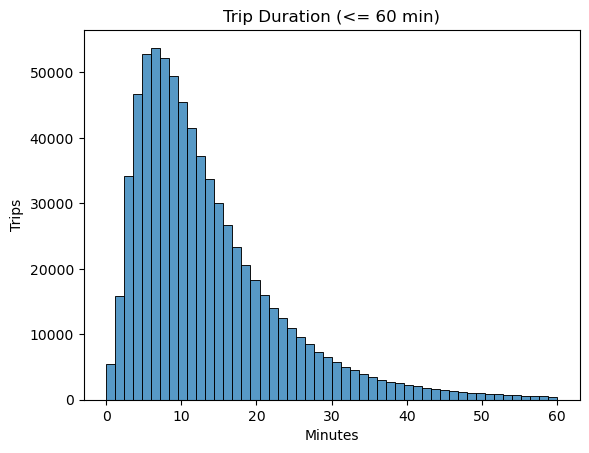

In [83]:
num = (df['trip_duration'] <= 3600).sum()
percentage = (df[df['trip_duration'] <= 3600].shape[0] / df.shape[0]) * 100

print(f"Number of trips under 60 minutes: {num}")
print(f"Percentage of trips under 60 minutes: {percentage:.2f}%")

# Histogram of trip durations under 60 min (3600 seconds)
sns.histplot((df[df['trip_duration'] <= 3600]['trip_duration']) / 60, bins=50)
plt.title("Trip Duration (<= 60 min)")
plt.xlabel("Minutes")
plt.ylabel("Trips")  # Set x-axis ticks from 0 to 60 minutes
plt.show()


**Inference ( Data Understanding )**:
1. Given datset is of 2 vendors and 9 different passanger counts
2. Avg journey duration is of 15.8 minutes but mode of the trips is approx 5.8 minutes (mode - more number of trips)
3. More than 99% of trips have duration less than 60 Minutes
4. Higher the trip duration lower the number of trips (after 6 minutes)
3. There are no null values in our data (Good thing) but there are 33 trips with 0 passengers which might be cancelled trips or errors.
5. There are approx 2400 trips with less than 30 seconds which also might indicate mis-entries because a typical taxi trip in NYC can't be less than 30secs


<h1 style="text-align:Left;"><strong>Data Cleaning</strong></h1>

###  Summary:

- Dropped rows with zero passengers and trip duration less than 30 seconds
- Reset the dataframe index after cleaning
- Checked for error between trip duration calculated and given trip duration and dropped if error < 60 seconds
- Checked for rows with unrealistic speeds based on the speed calclulation in Km/min and drop them based on a threshold fixed(1.5 Km/min) because they are outliers
- Checked all rows with unrealistic distances and dropped (might be due to ride cancellation in middle of trip)

In [84]:
# Drop rows with passenger_count = 0 since they are not valid/ not considered as trips
df.drop(df[df['passenger_count'] == 0].index, inplace=True)
df.drop(df[df['trip_duration'] <= 30].index, inplace=True)


In [85]:
df.reset_index(drop=True, inplace=True)

In [86]:
# Shape after dropping trips with 0 'passenger_count'
print(f"Number of trips after dropping necessary rows: {df.shape}") # for validation

Number of trips after dropping necessary rows: (726890, 11)


**Inference ( Data Cleaning )**:
1. Speeds >2 Km/min are dropped since they are unrealsitic in NYC (in **Data Transformation** section after calculating the speeds) and this cleaning can also be done by removing box plot's lower and upper quantile
2. Even after removing all the outliers using box plot or a treshold value there will still be some more threshold values, but they wont effect the accuracies when used for a Machine learning model because the outliers after removal are <1% of the full dataset.
3. Dropped trips with zero passengers and trips with duration less than 30seconds followed by resetting index

<h1 style="text-align:Left;"><strong>Data Transformation and Feature Engineering</strong></h1>

### Summary:

* Converted pickup and dropoff columns to datetime format and Extracted date, day name, weekday number, hour, and month and order the month in ascending order
* Calculated trip duration (in seconds) from pickup and dropoff times for finding outliers upon validation with given trip duration
* Categorized pickup and dropoff hours into time-of-day bins (e.g., morning, evening)
* Calculated Haversine distance between pickup and dropoff coordinates (Haversine vs great\_circle (geopy) – haversine is \~99.7% accurate and also fastest comparatively. So, it's better when used on large datasets)
* Calculated average speed in km/min for each trip
* Created combined pickup and dropoff coordinate strings for reverse geocoding


In [87]:
# Change object to datetime format for 'pickup_datetime' and 'dropoff_datetime'
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], dayfirst=True)
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'], dayfirst=True)


C:\Users\MY PC\AppData\Local\Temp\ipykernel_9536\2683827853.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], dayfirst=True)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_9536\2683827853.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'], dayfirst=True)


In [88]:
# Extract date, day, day number, time, hour, and month from pickup and dropoff datetime
df['pickup_date'] = df['pickup_datetime'].dt.date # date
df['pickup_day']=df['pickup_datetime'].dt.day_name()  # day name
df['pickup_day_no']=df['pickup_datetime'].dt.weekday # day number (0=Monday, 6=Sunday)
df['pickup_time'] = df['pickup_datetime'].dt.time # time (HH:MM:SS)
df['pickup_hour'] = df['pickup_datetime'].dt.hour # hour (0-23)
df['pickup_month']=df['pickup_datetime'].dt.month # month (1-12)
df['dropoff_date'] = df['dropoff_datetime'].dt.date
df['dropoff_day']=df['dropoff_datetime'].dt.day_name()
df['dropoff_day_no']=df['dropoff_datetime'].dt.weekday
df['dropoff_time'] = df['dropoff_datetime'].dt.time
df['dropoff_hour'] = df['dropoff_datetime'].dt.hour
df['dropoff_month']=df['dropoff_datetime'].dt.month
df['month'] = df['pickup_month'].apply(lambda x: calendar.month_name[x]) # month name (january, february)
df['pickup_day_num'] = df['pickup_datetime'].dt.day # day (1-31)

In [89]:
month = ['January', 'February', 'March', 'April', 'May', 'June']
# Convert 'month' column to categorical with the specified order
df['month'] = pd.Categorical(df['month'], categories=month, ordered=True)

weekday = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Convert 'weekday' column to categorical with ordered categories
df['pickup_day'] = pd.Categorical(df['pickup_day'], categories=weekday, ordered=True)

In [90]:
print(df['month'])


0         February
1            March
2         February
3          January
4         February
            ...   
726885         May
726886    February
726887       April
726888        June
726889     January
Name: month, Length: 726890, dtype: category
Categories (6, object): ['January' < 'February' < 'March' < 'April' < 'May' < 'June']


In [91]:
# Calculate trip duration in secs
df['trip_duration_calculated'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds()


In [92]:
# calculate the difference between calculated and given trip duration and check if they are almost equal
df['error'] = abs(df['trip_duration_calculated'] - df['trip_duration'])
print(f"The maximum no of seconds of error in between calculated and given trip duration: ",int(max(df['error'])),"secs")


The maximum no of seconds of error in between calculated and given trip duration:  0 secs


- Here the maximum of error obtained is 59 seconds which is less than 1 Min so it doesn't really make much difference. So, it's not required to drop the rows

In [93]:
# Data Cleaning (check for error in trip duration calculated and given)
if max(df['error']) < 60:
    df.drop(['trip_duration_calculated', 'error'], axis=1, inplace=True)
    print("The difference between calculated and given trip duration is less than 60 seconds so keeping the rows.")
else:
    print("The difference between calculated and given trip duration is more than 60 seconds so dropping the rows.")

The difference between calculated and given trip duration is less than 60 seconds so keeping the rows.


In [94]:
# categorize time of day into different time slots
def get_time_of_day(hour):
    if 6 <= hour < 9:
        return 'Morning'
    elif 9 <= hour < 12:
        return 'Late Morning'
    elif 12 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 17:
        return 'Late Afternoon'
    elif 17 <= hour < 19:
        return 'Evening'
    elif 19 <= hour < 23:
        return 'Late Evening'
    else:
        return 'Night'

df['pickup_timeofday'] = df['pickup_hour'].apply(get_time_of_day)


In [95]:
# Used Chat-GPT to create a function to calculate distance between two coordinates

# Earth radius in kilometers is taken into caluculation to assume earth radius and not to caluculate straight distance
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2]) # decimal degrees to radians
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

df['trip_distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
) # parameters passeed to func

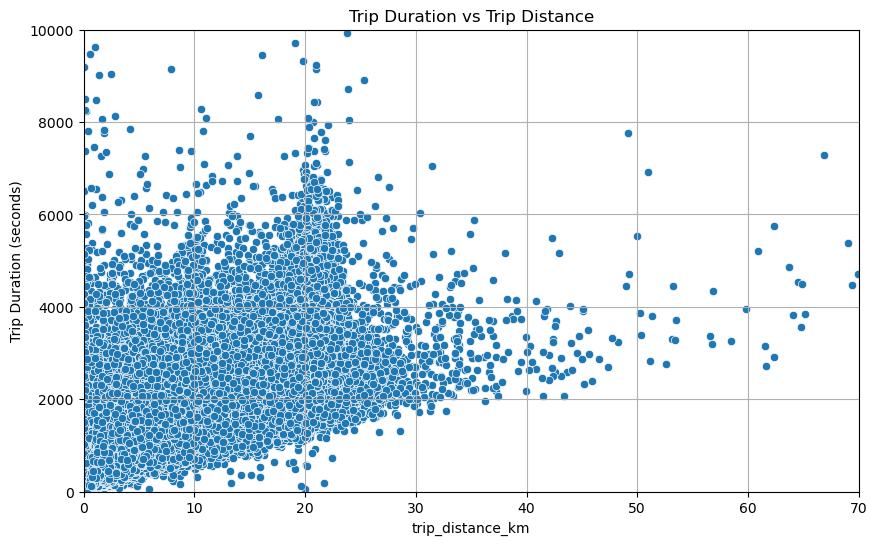

In [96]:
# Scatter plot of trip duration vs trip distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance_km', y='trip_duration', data=df)

plt.title('Trip Duration vs Trip Distance')
plt.ylabel('Trip Duration (seconds)')
plt.xlim(0, 70)
plt.ylim(0, 10000)
plt.grid(True)

- The above scatter plot shows that for the increase in distance it takes more trip duration which should be correct
- Majority of the trips are in the range of 0-6000sec which is 0-10 mins which is also correct upon verification of mode from df.describe() in data understanding
- Majority of trips are under 30 km which says that most of the trips are intercity

In [97]:
# Convert trip duration to minutes
df['trip_duration'] = (df['trip_duration'] / 60).astype(float)

# calculate speed in km/min which will be easy to do analysis on
df['speed(km/min)'] = df['trip_distance_km'] / df['trip_duration']

(726890, 28)


Text(0.5, 1.0, 'Box Plot of Speed beofre unrealistic speeds removal (km/min)')

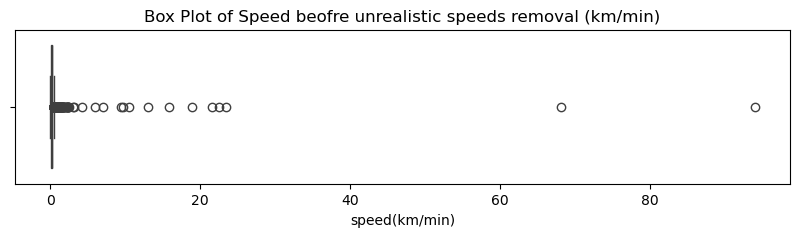

In [98]:
print(df.shape) # shape before dropping unrealistic speeds

# Box plot of trip speed
plt.figure(figsize=(10, 2))
sns.boxplot(x=df["speed(km/min)"])
plt.title("Box Plot of Speed beofre unrealistic speeds removal (km/min)")

In [99]:
# Drop rows with unrealistic speeds based on treshold set ( Data Cleaning )
df = df[(df['speed(km/min)'] <= 1.5) & (df['speed(km/min)'] >= 0.01)] 

- Using Z-score or Modified Z-Score or IQR or Quantile capping is removing more than 10% of the total data upon testing. So who knows which important data is getting missed, so it's better to remove outliers using some threshold and remove only unrealistic values rather than following these methods directly.
- Also there might be people who might be an elite customer travelling long distances who might be removed during the removal of outliers. So, using existing outlier removal methods is not recommended in this situation.

(722041, 28)


Text(0.5, 1.0, 'Box Plot of Speed after unrealistic speeds removal (km/min)')

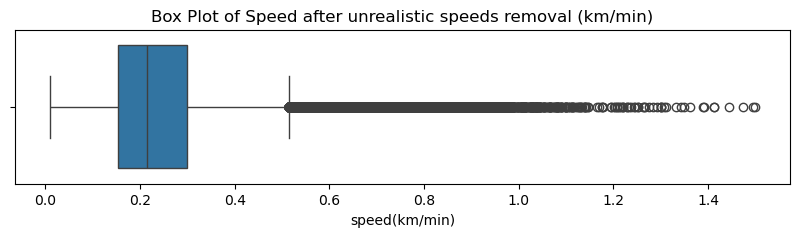

In [100]:
print(df.shape) # shape after dropping unrealistic speeds

# Box plot of trip speed
plt.figure(figsize=(10, 2))
sns.boxplot(x=df["speed(km/min)"])
plt.title("Box Plot of Speed after unrealistic speeds removal (km/min)")

- Most trips have reasonable, slow to moderate speeds typical for city traffic (NYC city speed rules allows to drive around in speed range 0.5-1.5 Km/min (upon analysis in google and conversion from mph to kmpermin)).
- A long right tail and many outliers tells the presence of abnormal data or possible noise.
- the scatter plot shows the corrrelation between distance in Km and duration in seconds which shows that major trips are under 20Km range and under 2000 seconds that is under 33 mins range

In [101]:
print(df[df.trip_distance_km == 0].shape)
print(df[df.trip_distance_km <= 0.1].shape)
print(df.shape) # shape before dropping trip distance less than 0.1 km

(0, 28)
(932, 28)
(722041, 28)


- There are no trips with trip distance = 0
- Which indicates the process being done is in right direction logically too since logically no one would get a taxi for 0 Km
- There are 932 trips with less than 0.1 km i.e. 100m trip which is very small distance for a trip in NYC. so, the trips must be dropped

In [102]:
# data cleaning (drop rows with trip distance less than 0.1 km)
df.drop(df[df.trip_distance_km <= 0.1].index, inplace=True)
print(df.shape) # shape after dropping trip distance less than 0.1 km for cross checking

(721109, 28)


**Inference ( Data Transformation and Feature Engineering )**:
1. Speeds >1.5 Km/min (treshold value) are dropped since they are unrealsitic in NYC (in **Data Transformation** section after calculating the speeds) and this cleaning can also be done by removing box plot's lower and upper quantile
2. For the above **box plot should not be used** beacuse since the majority of values lies in the range of 0.3-0.6 it shows all values above 0.8 Km/min as outlier upon calculating lower and upper bound using IQR and Q1 and Q3 value. Which is not a preferred methold in this case because they are still valid speeds (Data Cleaning step done in the section because variable not created by the data cleaning section)
3. There are some very small distances which are dropped too, since they are walkable distances or might be due to ride cancellation in middle of trip or just some unrealistic taxi covered distances in NYC. (Data Cleaning step done in the section because variable not created by the data cleaning section)

<h1 style="text-align:left;"><strong>Exploratory Visualizations with Insights</strong></h1>

### Summary:

* A **bar chart of trip counts by Vendor ID** was created to analyze how ride volumes are distributed between different vendors.
* A **segmented bar chart** showing **Vendor ID vs. Number of Trips** categorized by **time of day** (morning, afternoon, evening, night) helped assess vendor activity patterns across different time blocks.
* A **bar plot of trip counts by passenger count** was used to understand common group sizes and inform decisions on vehicle type allocation.
* A **bar plot comparing Vendor ID and average trip duration** was used to evaluate vendor performance in terms of trip efficiency.
* A **bar chart analyzing the relationship between passenger count and trip duration** helped identify trends in ride length based on group size.
* A **donut chart** was used to visualize the distribution of **trip duration categories** (short, medium, long) for a quick overview of trip types.
* A **pie chart** displayed the **passenger count distribution**, highlighting the most frequent group sizes among riders.


<Axes: xlabel='vendor_id', ylabel='count'>

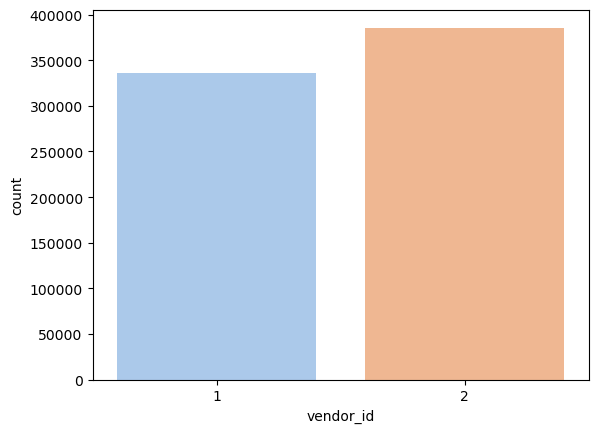

In [103]:
# plot the vendor id distribution
sns.countplot(x='vendor_id', hue='vendor_id', data=df, palette='pastel', legend=False)


  * **Vendor 2** has more trips (\~390,000) than **Vendor 1** (\~335,000).
  * Difference is notable but not too much.  
  
**Implication**: Vendor 2 might be more popular

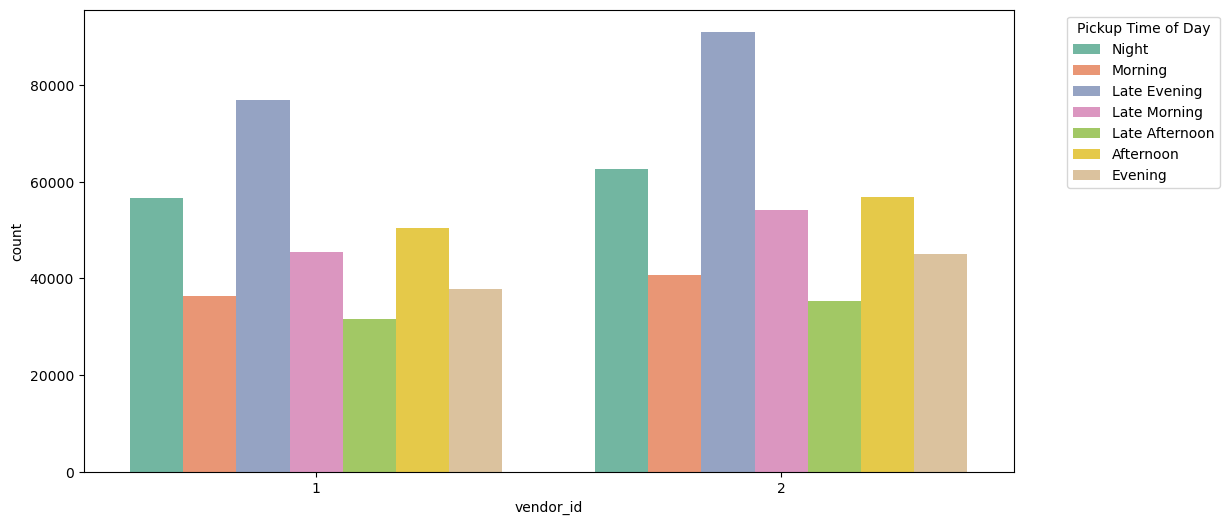

In [104]:
# Plotting no of trips by time of the day
plt.figure(figsize=(12, 6))
sns.countplot(x='vendor_id', hue='pickup_timeofday', data=df, palette='Set2', legend=True)
plt.legend(title='Pickup Time of Day', bbox_to_anchor=(1.05, 1), loc='upper left')

  * **Late Evening** is the peak period.
  * **Night** and **Afternoon** are the next busiest.
  * **Late Afternoon** and **Morning** are less busiest.  
  * Vendor 2 has most number of trips compared to vendor 1 on all days of week

**Implication:** Demand is highest during Late Evenings(peak period), possibly end-of-day travel by employees.

<Axes: xlabel='passenger_count', ylabel='count'>

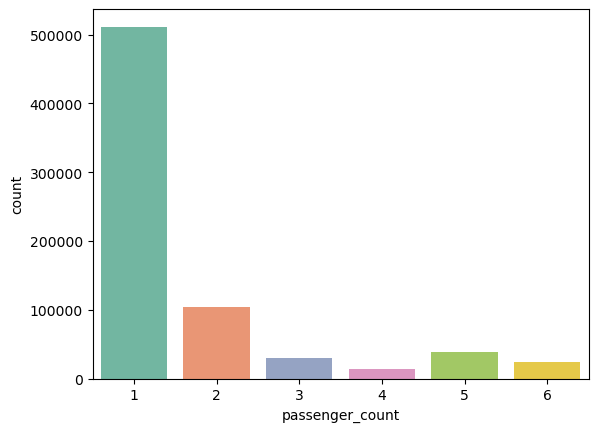

In [105]:
# Plot no of trips by passenger count
sns.countplot(x='passenger_count',hue='passenger_count',data=df, palette='Set2', legend=False)

  * Majority of trips (~500,000+) had only 1 passenger.  
  * Trips with 2 passengers are comparatively 5 times less than trips with 1 passenger (~100,000+).  
  * Trips with 3 to 6 passengers are very few in count.  

**Implication:** many prefer solo rides so, vendor should allocate smaller vehicles for more profit


<Axes: xlabel='vendor_id', ylabel='trip_duration'>

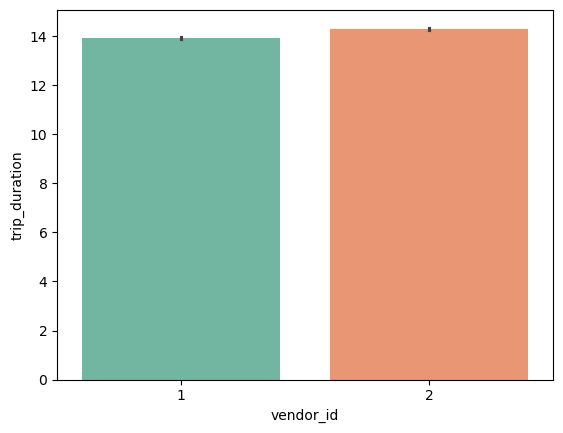

In [106]:
# Plot vendror id vs trip duration
sns.barplot(y='trip_duration', x='vendor_id', hue='vendor_id', data=df, estimator=np.mean, palette='Set2', legend=False)


* **Vendor 2** has only slightly longer average trip durations than **Vendor 1**.    

**Implication**: Even with having 55000 more trips vendor 2 has only slightly longer average which means even with having fewer trips vendor 2 had longer trip duration which says many may prefer vendor 2 for longer distances.

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9536\1686631150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passenger_count', y='trip_duration', data=avg_duration, palette='Set2')


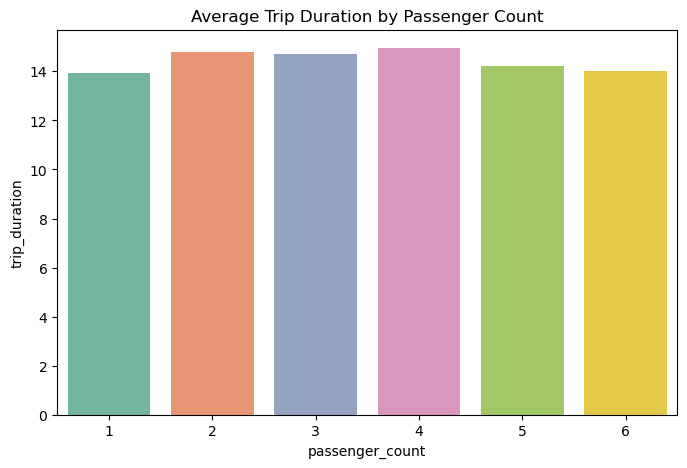

In [107]:
# plot passenger count vs trip duration
avg_duration = df.groupby('passenger_count')['trip_duration'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='passenger_count', y='trip_duration', data=avg_duration, palette='Set2')
plt.title('Average Trip Duration by Passenger Count')
plt.show()

* Trip with passenger count of 3,4 have slightly more average trip duration  

**Implication**:  trips with higher passenger count has more trip duration which might be becasue of usage of shared taxi for longer distances

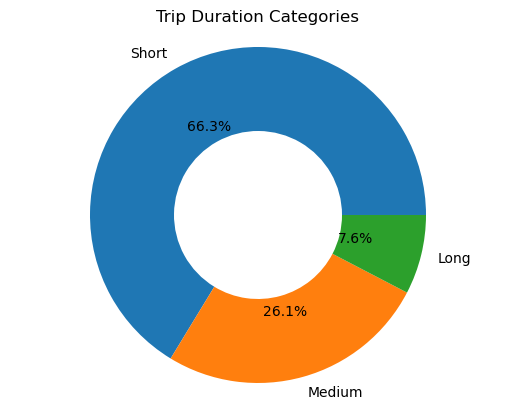

In [108]:
# plot donut chart for trip duration categories 
# bin trip durations into categories
bins = [0, 15, 30, float('inf')]  # 0–15min, 15–30min, 30+min
labels = ['Short', 'Medium', 'Long']
df['trip_duration_cat'] = pd.cut(df['trip_duration'], bins=bins, labels=labels)

duration_counts = df['trip_duration_cat'].value_counts().sort_index()

# modify wedge props for donut chart
plt.pie(duration_counts, labels=duration_counts.index, autopct='%1.1f%%', wedgeprops={'width': 0.5})
plt.title('Trip Duration Categories')
plt.axis('equal')
plt.show()


* Trip Duration as categories Short (0-15 Min), Medium (15-30 Min) and Long (30+ Min) distribution in a donut chart representation

**Implication**:  More number of rides are of short durations - This helps vendor analyse and decide on the type of vehicle needed for this scenarios.

<h1 style="text-align:left;"><strong>Statistical Insights</strong></h1>


<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250221120417227467/stat.webp" alt="GFG Statistics Image" height="400" width="600"/>

<p style="font-size:small; color:gray;">Image source: <a href="https://www.geeksforgeeks.org/statistics/" target="_blank" rel="noopener noreferrer">Geeks for Geeks</a></p>

- All the **descriptive statistics** methods mentioned in the image are shown in the below statistical insights continued by Hypothesis testing from **Inferential statistics** analysis.

In [109]:
df[['trip_duration', 'trip_distance_km', 'speed(km/min)']].describe()

,trip_duration,trip_distance_km,speed(km/min)
count,721109.000000,721109.000000,721109.000000
mean,14.123517,3.470406,0.241701
std,16.052676,3.955703,0.127438
min,0.516667,0.100109,0.010011
25%,6.683333,1.254463,0.153962
50%,11.083333,2.117813,0.214556
75%,17.933333,3.907109,0.298450
max,1439.850000,173.029358,1.498249


- The average trip duration is about 14.1 minutes, with most trips falling between 6.7 and 17.9 minutes, but some rare trips last much longer, up to 1439.85 minutes after removing the outliers.
- Trip distances are usually short, with a median = 2.1 km, but the maximum value = 173 km means some unusually long rides in the dataset.
- Avg speed is around 0.24 km/min, but range is in between 0.01 km/min and 1.49 km/min might due to NYC traffic or route differences.


In [110]:
mean = df[['trip_duration', 'trip_distance_km', 'speed(km/min)']].mean()
median = df[['trip_duration', 'trip_distance_km', 'speed(km/min)']].median()

mode_duration = df['trip_duration'].mode()[0] # mode() returns a DataFrame, so we need to access using the first row for each column
mode_distance = df['trip_distance_km'].mode()[0]
mode_speed = df['speed(km/min)'].mode()[0]

results = pd.DataFrame({ 'Mean': mean, 'Median': median, 'Mode': [mode_duration, mode_distance, mode_speed]})
results

,Mean,Median,Mode
trip_duration,14.123517,11.083333,5.800000
trip_distance_km,3.470406,2.117813,0.650411
speed(km/min),0.241701,0.214556,0.010011


- The order of trip duration, trip distance, and speed is in order Mean > Median > Mode. 
- This says that most trips are short and slow, with a few extreme affecting averages (Median values are best central tendency to identify presence of extreme values).
- Most (mode) trips are of 0.65km distance and of 5.8 min trip duration from the cleaned data 
- Mean is very sensitive to extreme values
- The above data is useful for vendors to decide the type of vehicle based on the distance need to be covereed

In [111]:
variance = df.var(numeric_only=True)
std_dev = df.std(numeric_only=True)
range = df.max(numeric_only=True) - df.min(numeric_only=True)

stats = pd.DataFrame({ 'Variance': variance, 'Standard_Deviation': std_dev, 'Range': range})
stats

,Variance,Standard_Deviation,Range
vendor_id,0.248784,0.498782,1.000000
passenger_count,1.721783,1.312167,5.000000
pickup_longitude,0.001429,0.037807,2.217918
pickup_latitude,0.000777,0.027873,1.515232
dropoff_longitude,0.001275,0.035705,2.064034
dropoff_latitude,0.001036,0.032179,1.187466
trip_duration,257.688400,16.052676,1439.333333
pickup_day_no,3.819769,1.954423,6.000000
pickup_hour,40.967691,6.400601,23.000000
pickup_month,2.823821,1.680423,5.000000


- trip_duration, trip_distance_km has more variance, means they have good range of travel times and distances
- pickup_hour, dropoff_hour, and hour have average variance (Std dev ≈ 6.4), means good spread of data across different times of the day.
- Coordinates have very low variance, means most rides occur in a same area or nearby areas.


In [112]:
ct = pd.crosstab(df['pickup_day'], df['passenger_count'])
ct

passenger_count,1,2,3,4,5,6
pickup_day,,,,,,
Monday,67184,12829,3580,1668,4715,2987
Tuesday,72953,13095,3728,1613,5379,3343
Wednesday,75901,13664,3774,1752,5531,3331
Thursday,78583,14511,3978,1784,5686,3565
Friday,78647,15791,4454,2131,5843,3599
Saturday,72838,18441,5254,2724,5969,3766
Sunday,65359,15690,4645,2232,5385,3207


- The above cross tab function shows mostly passeger count of 1,2 are hiring taxi because all the passenger count of 1,2 are above 10,000 whereas other have less than 10,000 indicating mostly a car has 1 or 2 passengers in most cases.
- The data also says the crowd that used taxi on particular days which helps vendors to analyse and assign more cars based on the day and no of seats.

In [113]:
avg_stats_per_vendor = df.groupby('vendor_id')[['trip_duration', 'trip_distance_km']].mean().reset_index()
print(avg_stats_per_vendor)


   vendor_id  trip_duration  trip_distance_km
0          1      13.930910          3.435058
1          2      14.291006          3.501145


- The table shows average duration and average trip distance covered by each vendor for a single trip
- Average duration is not same as most frequent duration (mode) (This data is 2 snippets above)
- This data is not really useful for analysis but can be helpful for comparison in between vendors

(0.0, 60.0)

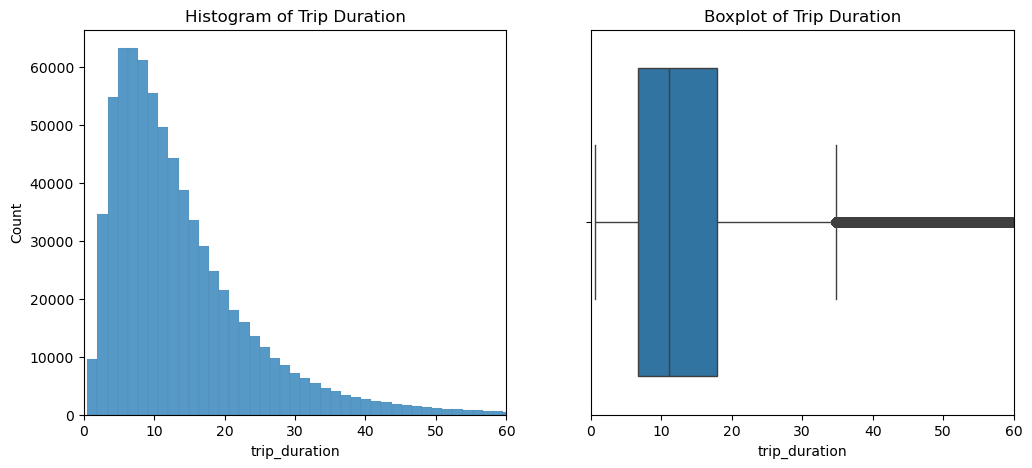

In [114]:
# Histogram and boxplot of trip_duration
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df['trip_duration'], bins=1000)
plt.title('Histogram of Trip Duration')
plt.xlim(0, 60)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['trip_duration'])
plt.title('Boxplot of Trip Duration')
plt.xlim(0, 60)



- This above plots shows the graphical representation (descriptive statistics) of trip duration
- The trip mduration mainly lasts between 8-18 Mins and most of the trips has less duration and as duration increase no of trips kept dropping (from the histogram plot).

Text(0.5, 1.0, 'Correlation Matrix')

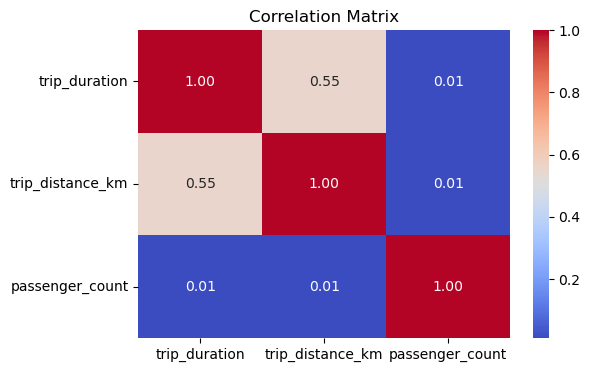

In [115]:
corr_matrix = df[['trip_duration', 'trip_distance_km', 'passenger_count']].corr()

# heat map
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

- The above correlation heat plot says that the trip duartion and trip distance are highly correlated which is true logically too so the analysis being done as of now is in right direction 
- Also the high correlation says that if trip duartion is changed then trip distance will be changed mostly and also vice versa.

Text(0.5, 1.0, 'Correlation Matrix')

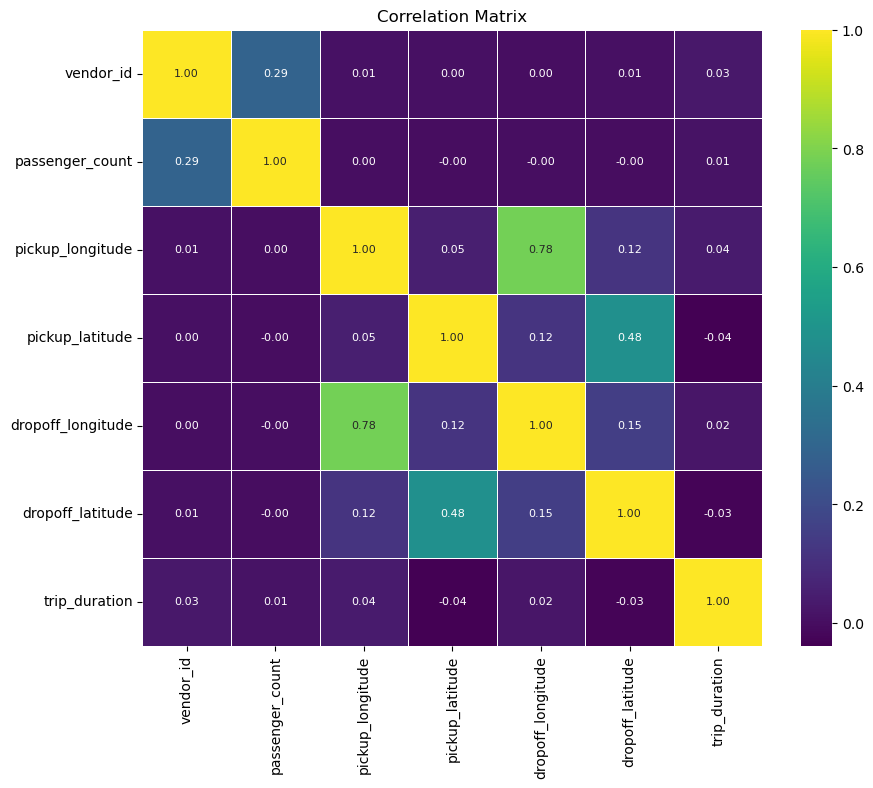

In [116]:
# plot heat map for all the columns
df1 = pd.read_csv("nyc_taxi_trip_duration.csv") # Load the dataset again for correlation analysis since many new features were added
corr_matrix = df1.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
# Plot the heatmap for correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix")

- vendor_id and passenger_count have a weak positive correlation (0.29), might be beacuse they are not really related.
- Most variables are weakly or very lowly correlated, means no relationship between those features
- pickup_longitude and dropoff_longitude have a high positive correlation (0.78), means trips majorly in similar horizontal paths.
- pickup_latitude and dropoff_latitude have medium correlation (0.48), means trips majorly similar vertical paths.
- trip_duration has very weak correlation with all other features except trip distance from pervious heatmap.

In [117]:
subset = df[df['trip_duration'] <= 60]
trip = len(subset)

# Trips with exactly duartion of less than 15 minutes (given that the trip has less than 1 hour duartion)
trip_1 = len(subset[subset['trip_duration'] <= 15])
prob = (trip_1 / trip)*100

print(f"Conditional Probability (<15 min | < 1 hour): {prob:.2f} percentage")

Conditional Probability (<15 min | < 1 hour): 66.76 percentage


- The above value shows the conditional probability of trip being less than 15 minutes given the condition trip is less than 60 min/ 1 hour
- There are multiple such scenaarios where this conditional probability concept can be used for statistical insight analysis

In [118]:
from statsmodels.stats.proportion import proportions_ztest

# hypothesis - Vendor 1 has more trips than Vendor 2 in February

feb = df[df['month'] == 'February'] # Filter data for February
n = len(feb)
x = (feb['vendor_id'] == 1).sum() # Vendor 1 trips in February

# Z-test (because the population is large)
stat, p_value = proportions_ztest(count=x, nobs=n, value=0.5, alternative='larger')
print(f"Z = {stat:.4f} \nP-value = {p_value:.4f} ")

Z = -25.8775 
P-value = 1.0000 


* Negative Z-score means Vendor 1’s share of trips in February is less than Vendor 2’s share.
* P-value = 1 shows no evidence that Vendor 1 had more trips than Vendor 2 in February.
* Fail to reject the null hypothesis because the p-value > 0.05.
* Conclusion: Vendor 1 did not have more trips than Vendor 2 in February rather the hypothesis suggests Vendor 1 had fewer trips that month.


In [119]:
# hypothesis - proportion of trips at hour 10 is equal to 32430

hour_dat = df[df['pickup_hour'] == 10]
count1 = len(hour_dat)
total_trips = len(df)
p0 = 32430 / total_trips 
p_hat = count1 / total_trips # Observed proportion of trips at hour 10

# Z-test (because the population is large)
stat, p_value = proportions_ztest(count=count1, nobs=total_trips, value=p0, alternative='two-sided')

print(f"No of trips at hour 10 for comparison: {count1}")
print(f"Hypothesis trips at hour 10: 32430")
print(f"Z = {stat:.4f} \nP-value = {p_value:.4f}")

No of trips at hour 10 for comparison: 32403
Hypothesis trips at hour 10: 32430
Z = -0.1535 
P-value = 0.8780


- The slightly positive Z-score indicates the observed trips at hour 10 are slightly more than the hypothesized 32430.
- Since the P-value is greater than 0.05, we fail to reject null hypothesis.
- Conclusion: The number of trips at hour 10 differs slightlu less than 32430(hypothesis value).

<h1 style="text-align:left;"><strong>Geographical Insights</strong></h1>


In [120]:
# Round coordinates to 3 decimal places
# 1 decimal degree ≈ 111 km => 0.000001° ≈ 0.111 meters and 0.0001° ≈ 11.1 meters (used google for the data) 
# so worst case the location is rounded off by 10 meteres approx
df['pickup_latitude'] = df['pickup_latitude'].round(3)
df['pickup_longitude'] = df['pickup_longitude'].round(3)

# Top 20 most frequent pickup locations
pickup_counts = df.groupby(['pickup_latitude', 'pickup_longitude']).size().reset_index(name='trip_count')
top_pickups = pickup_counts.sort_values('trip_count', ascending=False).head(20)
top_pickups

,pickup_latitude,pickup_longitude,trip_count
5432,40.751,-73.994,4358
7331,40.774,-73.873,4313
5360,40.750,-73.991,3854
311,40.645,-73.782,3501
7333,40.774,-73.871,3373
5359,40.750,-73.992,3062
6958,40.769,-73.863,2583
7037,40.770,-73.864,2438
314,40.645,-73.777,2218
5932,40.757,-73.990,2187


* Above mentioned table contained coordinates of 20 most frequently visited locations
1. decimal degree ≈ 111 km
1. 0.000001° ≈ 0.111 meters
2. 0.0001° ≈ 11.1 meters
2. 0.001° ≈ 111.1 meters  
- In worst case the location is rounded off by 100 meteres approx which is fine

In [121]:
# used Chat-GPT for the reverse geocoding function code

# reverese geocode the pickup coordinates to get addresses 
geolocator = Nominatim(user_agent="nyc-taxi-lookup")

df['pickup_coordinates'] = df['pickup_latitude'].astype(str) + "," + df['pickup_longitude'].astype(str)
df['dropoff_coordinates'] = df['dropoff_latitude'].astype(str) + "," + df['dropoff_longitude'].astype(str)

top_pickups = df['pickup_coordinates'].value_counts().head(10)
top_dropoffs = df['dropoff_coordinates'].value_counts().head(10)

def reverse_geocode(lat, lon):
    try:
        location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
        return location.address if location else "Unknown"
    except:
        return "Error"

def print_top_unique_locations(coords, N=5):
    printed_addresses = set()
    count = 0
    for coord in coords.index:
        lat, lon = map(float, coord.split(","))
        address = reverse_geocode(lat, lon)
        if address not in printed_addresses:
            print(f"{coord} → {address}")
            printed_addresses.add(address)
            count += 1
            if count == N:
                break
        time.sleep(1)

print("Top 3 Unique Pickup Locations:")
print_top_unique_locations(top_pickups, N=3)
print("\nTop 3 Unique Dropoff Locations:")
print_top_unique_locations(top_dropoffs, N=3)


Top 3 Unique Pickup Locations:
40.751,-73.994 → Madison Square Garden, 4, Pennsylvania Plaza, Garment District, Chelsea District, Manhattan, New York County, City of New York, New York, 10001, United States
40.774,-73.873 → Terminal B, Terminal B Departures, Queens, Queens County, City of New York, New York, 11371, United States
40.75,-73.991 → 15, 7th Avenue, Garment District, Chelsea District, Manhattan, New York County, City of New York, New York, 10001, United States

Top 3 Unique Dropoff Locations:
40.75038909912109,-73.99468231201173 → 8th Avenue, Manhattan Community Board 5, Manhattan, New York County, City of New York, New York, 10001, United States
40.75046157836913,-73.99466705322266 → 430, 8th Avenue, Manhattan Community Board 4, Manhattan, New York County, City of New York, New York, 10001, United States
40.75046157836913,-73.99462127685547 → 431, 8th Avenue, Manhattan Community Board 4, Manhattan, New York County, City of New York, New York, 10001, United States


* Reverse-geocoded to find top pickup and dropoff locations using latitude and longitude

  * **Top Pickup Locations:**

    * 137th Street-City College, Broadway
    * Central Terminal Drive, Queens
    * LaGuardia Airport, Marine Terminal Road, Queens
  * **Top Dropoff Locations:**

    * 137th Street-City College, Broadway
    * 8th Avenue, Manhattan Community Board 5, Manhattan
    * 430, 8th Avenue, Manhattan Community Board 4, Manhattan

Text(0, 0.5, 'Latitude')

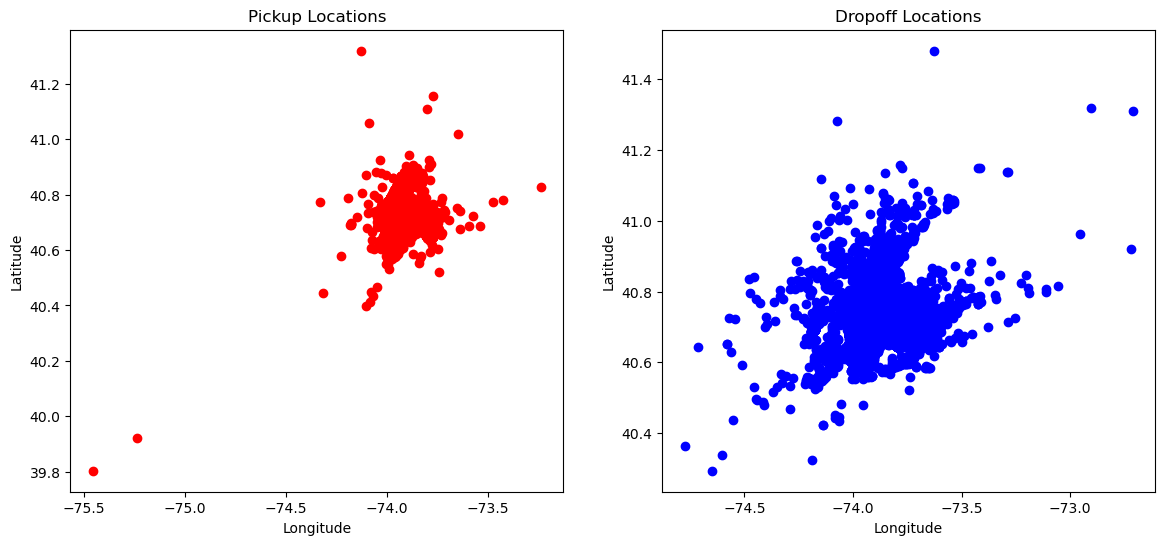

In [122]:
# plotting scatter plot for pickup and dropoff locations coordinates
pickup_coords = list(zip(df['pickup_latitude'], df['pickup_longitude']))
dropoff_coords = list(zip(df['dropoff_latitude'], df['dropoff_longitude']))

pickup_lats, pickup_lons = zip(*pickup_coords)
dropoff_lats, dropoff_lons = zip(*dropoff_coords)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6))

ax0.scatter(pickup_lons, pickup_lats, c='red')
ax0.set_title("Pickup Locations")
ax0.set_xlabel("Longitude")
ax0.set_ylabel("Latitude")

ax1.scatter(dropoff_lons, dropoff_lats, c='blue')
ax1.set_title("Dropoff Locations")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

* A **scatter plot of pickup vs. drop-off locations**, using latitude and longitude coordinates, is used to highlight no of rides to identify the most used traveled routes and hotspots.
* Both plots shows mostly in Manhattan (used google maps based on coordintes).
* A few outlier points appear far from hotspots coordiantes, which maybe because of **GPS errors or rare long-distance trips**.

**Implications:**
1. Major taxi demand in NYC’s commercial and tourist places.
2. Longer passenger destinations, including residential areas and airports (from top 3 visited spots using reverse geocoding).  

Text(0.5, 1.0, 'Dropoff Location Density')

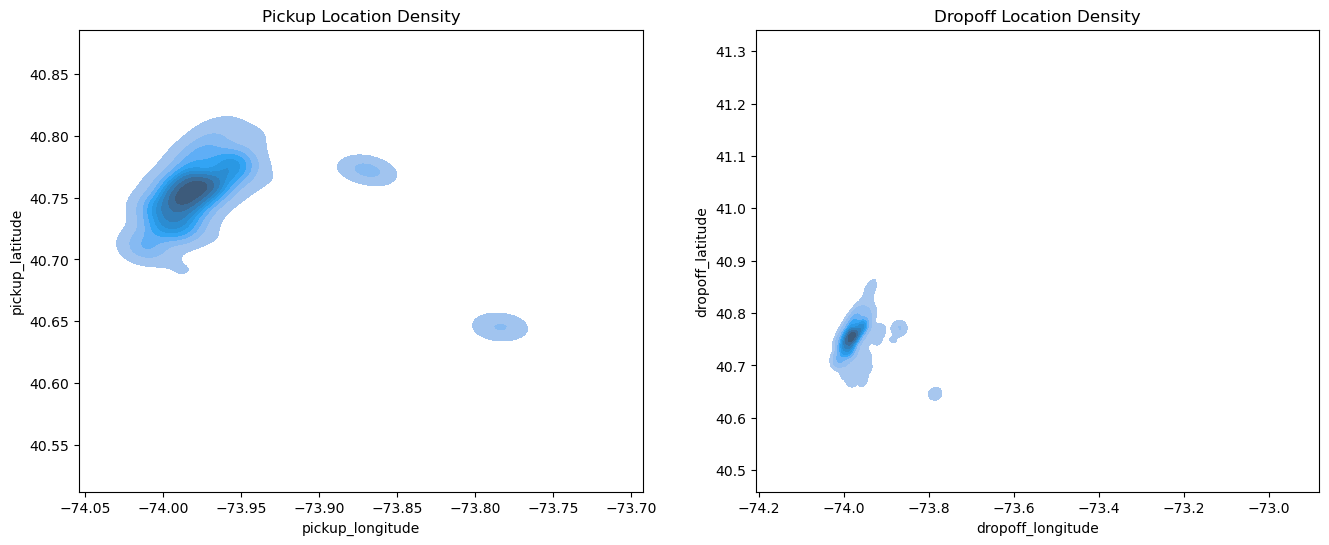

In [123]:
# plotting pickup and dropoff locations coorinates density
sample = 10000  # Due to huge datset sample the data to make KDE plots much faster
df_sample = df.sample(n=min(sample, len(df)))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(x='pickup_longitude', y='pickup_latitude', data=df_sample, fill=True, ax=ax0)
ax0.set_title('Pickup Location Density')
sns.kdeplot(x='dropoff_longitude', y='dropoff_latitude', data=df_sample, fill=True, ax=ax1)
ax1.set_title('Dropoff Location Density')


* Another kind of represntation compared to the previous scatter plot 

**Implications:** Darker the color, higher the pickups and drops from that place

In [124]:
# used chat-gpt to create function using plotly to plot the map with top 20 pickup locations

# plotting top 20 pickup locations on map
# Round coordinates(for 4 decimal places - 100m range) and calculate top pickup locations
top_pickups = df.assign(pickup_latitude=df['pickup_latitude'].round(4), pickup_longitude=df['pickup_longitude'].round(4)
).groupby(['pickup_latitude', 'pickup_longitude']).size().reset_index(name='count').sort_values('count', ascending=False).head(20)

px.scatter_mapbox(top_pickups, lat='pickup_latitude', lon='pickup_longitude', size='count', size_max=10, hover_name='count', 
zoom=9, mapbox_style='open-street-map', title='Top 20 Most Frequent Pickup Locations').show()

- The Top 20 Pickup spots overlapping almost gives us 3 locations

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9536\3655502007.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Text(0, 0.5, 'Avg Trip Duration (seconds)')

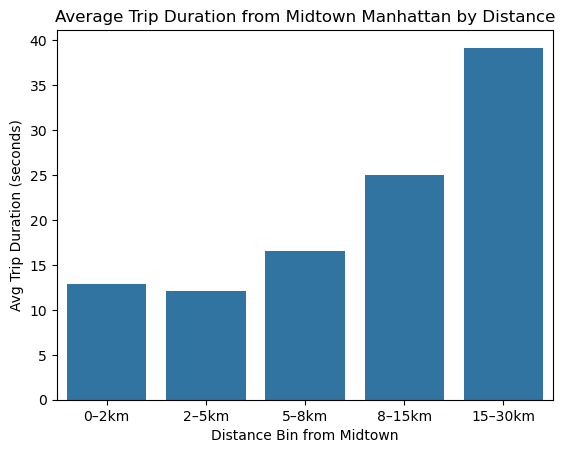

In [125]:
# avg trip duration from Midtown Manhattan
# used google to learn about haversine library for distance calculation

from haversine import haversine  
midtown_coords = (40.7549, -73.9840) # Midtown Manhattan coordinates (from scatter plot)(one of the most vivited locations in NYC)

# distance from Midtown Manhattan
df['midtown_distance_km'] = df.apply( lambda row: haversine(midtown_coords, (row['dropoff_latitude'], row['dropoff_longitude'])), axis=1)

df['distance_bin'] = pd.cut( df['midtown_distance_km'], bins=[0, 2, 5, 8, 15, 30], labels=['0–2km', '2–5km', '5–8km', '8–15km', '15–30km'] )

# Average trip duration per bin
zone_duration = df.groupby('distance_bin')['trip_duration'].mean().reset_index()

sns.barplot(x='distance_bin', y='trip_duration', data=zone_duration)
plt.title('Average Trip Duration from Midtown Manhattan by Distance')
plt.xlabel('Distance Bin from Midtown')
plt.ylabel('Avg Trip Duration (seconds)')


* The chart shows average trip duration from Midtown Manhattan (one of the most visited location - using scatter/density plot analysis  from above) to drop-off locations shows how far taxis typically travel from the hotspot.
* This insight lets vendor know how many and what type of taxis need to be placed in Midtown Manhattan, increasing availability at places with more trip demand.


<h1 style="text-align:left;"><strong>Time Series Insights</strong></h1>


In [126]:
# count of trips by month 
df['month'].value_counts().sort_index()

month
January     113083
February    118077
March       126959
April       124232
May         122741
June        116017
Name: count, dtype: int64

- The given dataset has good balanced values from all months of the first 2 quarters of the year (A Proper balanced datset)

<Axes: xlabel='pickup_hour', ylabel='count'>

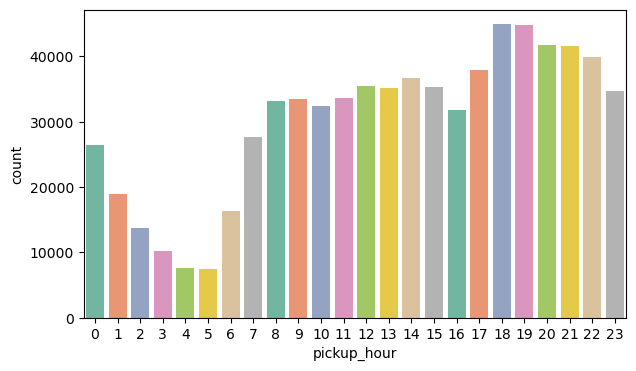

In [127]:
# bar plot for number of trips by hour of the day (0-23)
plt.figure(figsize=(7,4))
sns.countplot(x='pickup_hour', hue='pickup_hour', data=df, palette='Set2', legend=False)

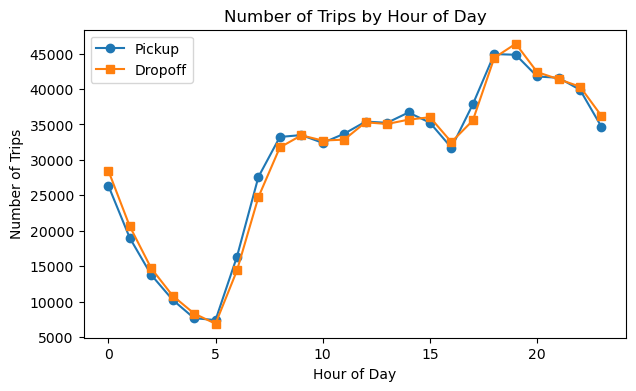

In [128]:
# line plot of number of trips by hour of day
pickup_hourly_counts = df['pickup_hour'].value_counts().sort_index()
dropoff_hourly_counts = df['dropoff_hour'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(pickup_hourly_counts.index, pickup_hourly_counts.values, marker='o', label='Pickup')
plt.plot(dropoff_hourly_counts.index, dropoff_hourly_counts.values, marker='s', label='Dropoff')
plt.title("Number of Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.legend()


- Both pickups and dropoffs reduce after midnight, hitting the least around 4-5 AM.
- There is a sharp increase in trips starting at 6 AM, peaking around 9-10 AM. This might because of period traveling to work or school.
- From late morning to afternoon 11 AM - 3 PM, the number of trips remains stable.
- Similarly, A second surge in trips occurs between 4 PM and 7 PM, with the peak around 6-7 PM. This likely represents the evening commute as people return home from schools or work.

<Axes: xlabel='pickup_timeofday', ylabel='count'>

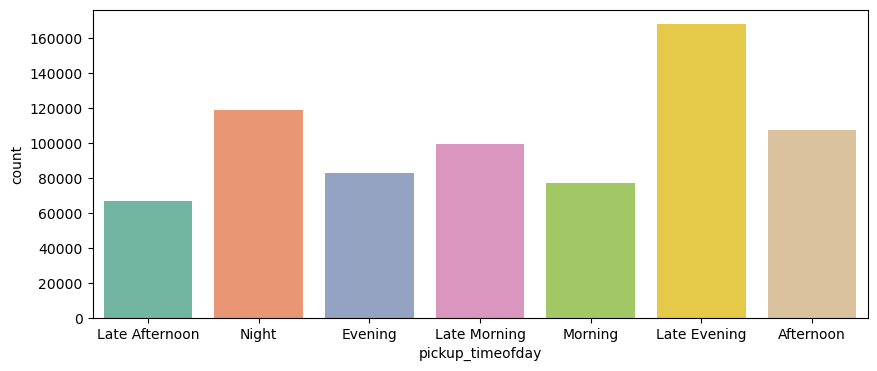

In [129]:
# plot for pickup time of day 
plt.figure(figsize=(10,4))
sns.countplot(x='pickup_timeofday', hue='pickup_timeofday', data=df, palette='Set2', legend=False)

  * **Late Evening** is the peak period.
  * **Night** and **Afternoon** are the next busiest.
  * **Late Afternoon** and **Morning** are less popular.  

**Implication:** Demand is highest during Late Evenings.

<Axes: xlabel='pickup_day', ylabel='count'>

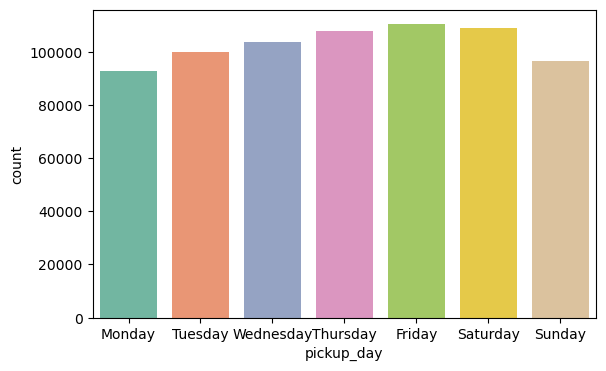

In [130]:
# plotting trip day on number of trips
plt.figure(figsize=(6.5,4))
sns.countplot(x='pickup_day', hue='pickup_day', data=df, palette='Set2', legend=False)

* **Weekdays (Tue–Sat)** see higher trip activity than **Sunday and Monday**.  
**Implication**: Demand is stronger weekdays - might be due to employes and students travels - Vendor can consider varying prices accordingly.

<Axes: xlabel='month', ylabel='count'>

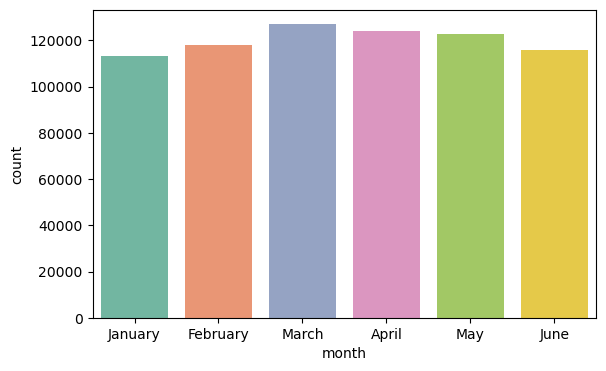

In [131]:
# plot on trip month by count of trips
plt.figure(figsize=(6.5,4))
sns.countplot(x='month', hue='month', data=df, palette='Set2', legend=False)

-  There are comparatively more trips in Month of march and april which can be due to any reason so vendor should put up some offers or program to boost his sales during the months with fewer trips which will attract customers.

<Axes: xlabel='pickup_day', ylabel='trip_distance_km'>

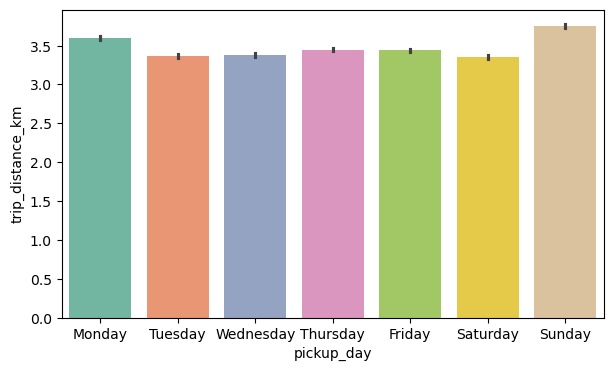

In [132]:
# Avg distance travelled on each dday of the wwek (Monday - Sunday)
plt.figure(figsize=(7, 4))
sns.barplot(x='pickup_day', hue='pickup_day', y='trip_distance_km', data=df, palette='Set2', legend=False)

* Sunday relatively have high average distance covered

**Implication:**  Indicates poeple travel more on weekends for exploration or shopping and similiar such things

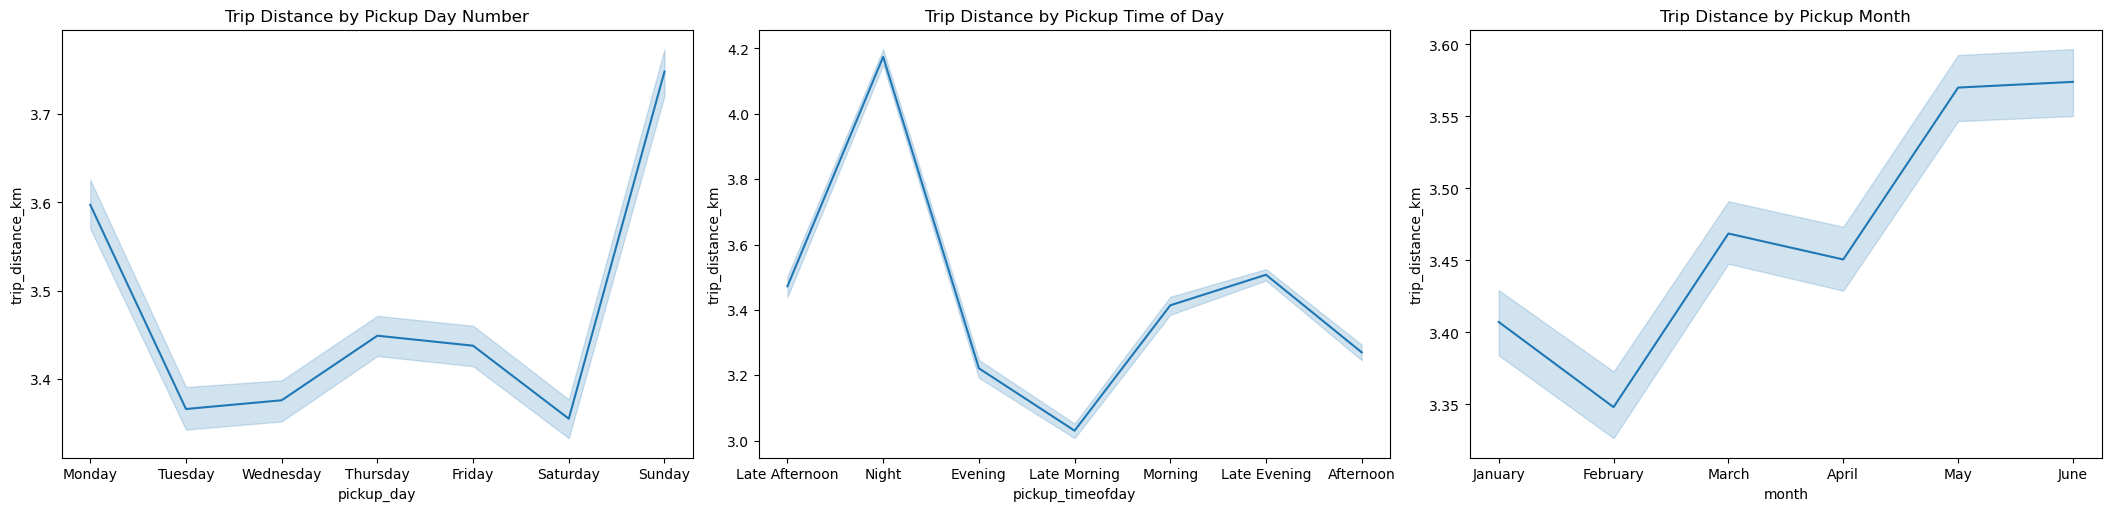

In [133]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5), constrained_layout=True)

# Plot 1 - Trip Distance by Pickup Day Number
# Plot 2 - Trip Distance by Pickup Time of Day
# Plot 3 - Trip Distance by Pickup Month

sns.lineplot(ax=ax[0], x='pickup_day', y='trip_distance_km', data=df)
sns.lineplot(ax=ax[1], x='pickup_timeofday', y='trip_distance_km', data=df)
sns.lineplot(ax=ax[2], x='month', y='trip_distance_km', data=df)

ax[0].set_title("Trip Distance by Pickup Day Number")
ax[0].tick_params(axis='x', labelsize=10)

ax[1].set_title("Trip Distance by Pickup Time of Day")
ax[1].tick_params(axis='x', labelsize=10)

ax[2].set_title("Trip Distance by Pickup Month")
ax[2].tick_params(axis='x', labelsize=10)


* More distance covered during weekends (Saturday and Sunday)
* More distance covered during night time hours  
* Distance covered kept on incresing as the months followed and has the peak at **June**

**Implication:** This shows travel patterns peaks during weekends and night time, which could help vendor these time periods to boost his sales.


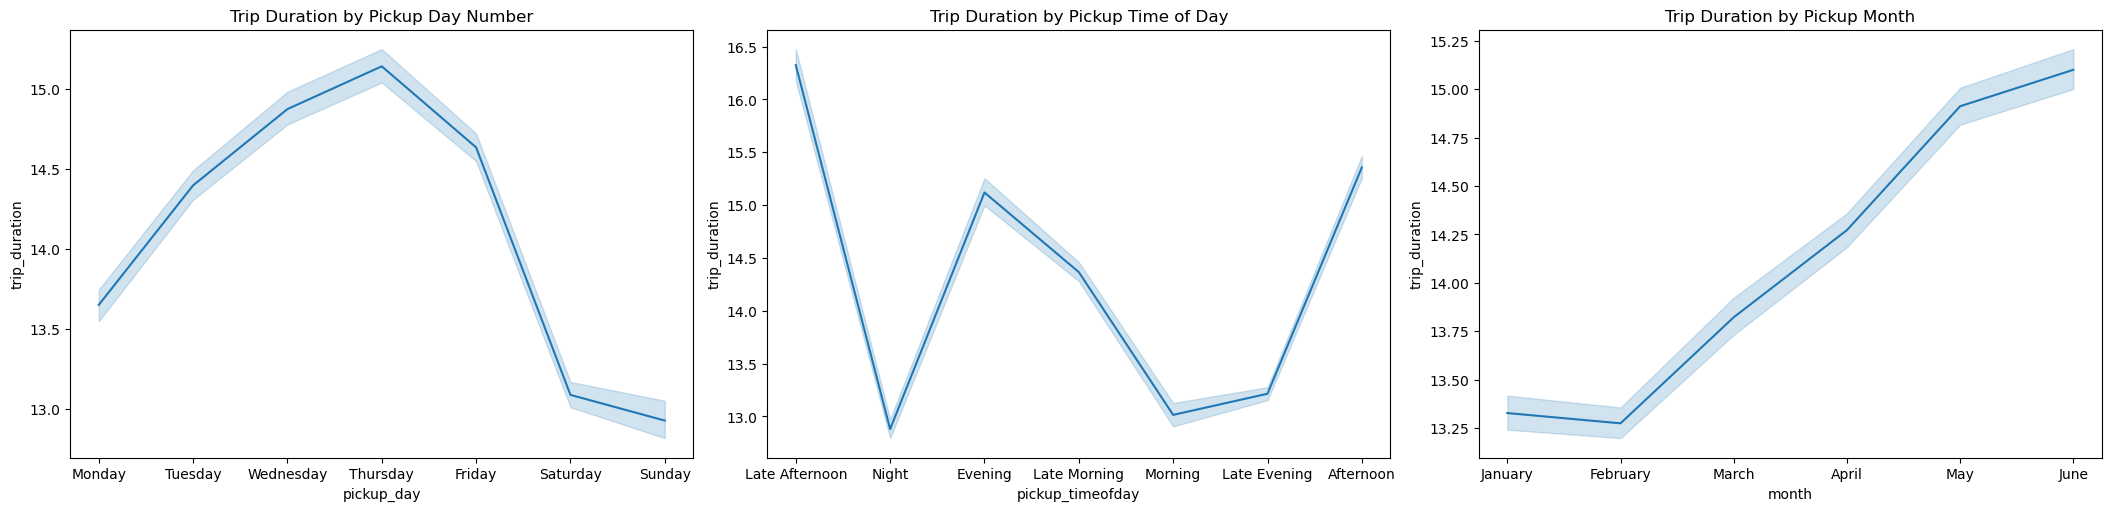

In [134]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5), constrained_layout=True)

# Plot 1 - Trip Duration by Pickup Day Number
# Plot 2 - Trip Duration by Pickup Time of Day
# Plot 3 - Trip Duration by Pickup Month

sns.lineplot(ax=ax[0], x='pickup_day', y='trip_duration', data=df)
sns.lineplot(ax=ax[1], x='pickup_timeofday', y='trip_duration', data=df)
sns.lineplot(ax=ax[2], x='month', y='trip_duration', data=df)

ax[0].set_title("Trip Duration by Pickup Day Number")
ax[0].tick_params(axis='x', labelsize=10)

ax[1].set_title("Trip Duration by Pickup Time of Day")
ax[1].tick_params(axis='x', labelsize=10)

ax[2].set_title("Trip Duration by Pickup Month")
ax[2].tick_params(axis='x', labelsize=10)


* Longer trip durations are observed during mid-week (Wednesday to Friday)
* Trips tend to last longer in the afternoons and evenings
* Trip duration gradually increases over the months, reaching a peak in **June**  

**Implication:** This will help vendor assign vehicles based on distances need to be covered on specific periods of day and days of weeek.

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9536\947555755.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



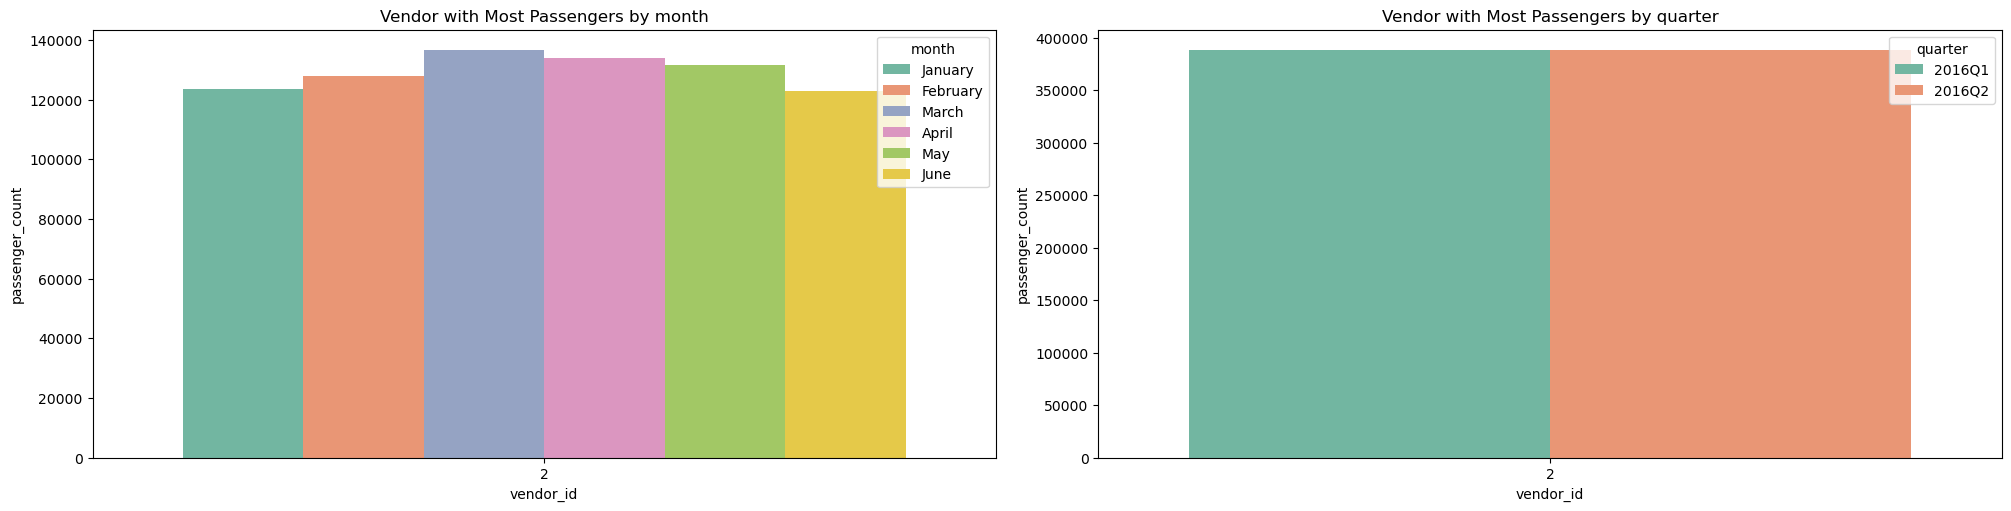

In [135]:
# vendor monthly and quarterly analysis
def vendor_subplot(df):
    fig, ax = plt.subplots(1, 2, figsize=(20, 5), constrained_layout=True)
    for i, p in enumerate(['month', 'quarter']):
        if p == 'quarter': df[p] = df['pickup_datetime'].dt.to_period('Q')
        group = df.groupby([p, 'vendor_id'], observed=True)['passenger_count'].sum().reset_index()
        top = group.loc[group.groupby(p)['passenger_count'].idxmax()]
        sns.barplot(ax=ax[i], x='vendor_id', y='passenger_count', hue=p, data=top, palette='Set2')
        ax[i].set_title(f"Vendor with Most Passengers by {p}")
vendor_subplot(df)


* **Vendor 2** consistently recorded the highest total passenger count across both monthly and quarterly periods in the bivariate analysis of vendor ID and passenger count.  

**Implication:**  Indicates higher trust or service quality by Vendor 2. This data can be of helpful for customers to analyse and book taxi from that particular vendor and also helpful for vendor to analyse their performane and make adjustments to his business policies, offferas.

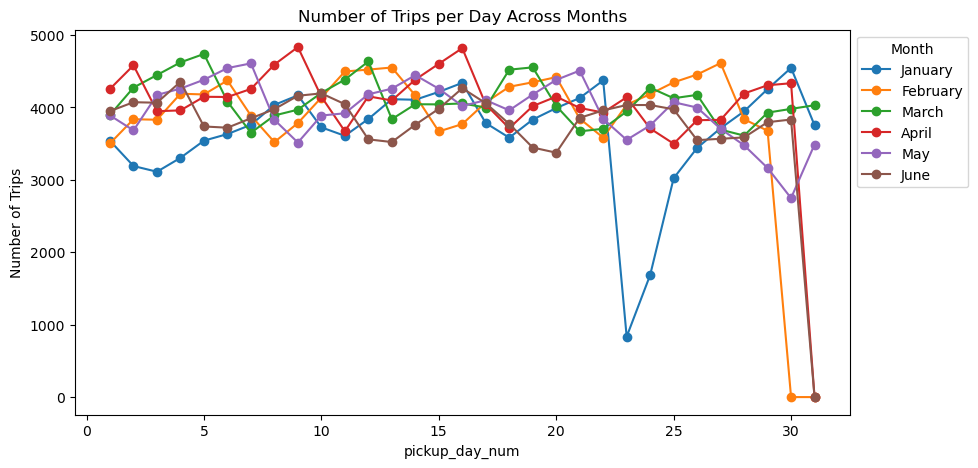

In [136]:
# ploting number of trips per day avcross months
trip_calendar = df.groupby(['pickup_day_num', 'month'], observed=False).size().unstack()

trip_calendar.plot(figsize=(10, 5), marker='o')
plt.title('Number of Trips per Day Across Months')
plt.ylabel('Number of Trips')
plt.legend(title='Month', bbox_to_anchor=(1, 1), loc='upper left')


- February, April, and June drops to **0** at the end of the month because there is no 31st day in these months
- January drops sharply on day 23.
- March and April show steady trip numbers without major drops in middle.
- Most months have daily trips between **3,000 and 4,500**.


**Implication:** Daily trip total is generally stable with some drops which might be due to data issues or external factors like holidayss


<h1 style="text-align:left;"><strong>Business Insights</strong></h1>

* A large portion of rides consists of 1–2 passengers taking short to medium-distance trips, typically lasting less than 10 minutes. These trips are heavily concentrated in areas such as Manhattan, Queens, and Broadway. To boost profit, vendors should consider sending smaller, fuel-efficient vehicles in these zones, especially during peak hours.

* **Hotspots** - Most pickups and drop-offs occur within the core metropolitan area. By keeping more drivers in these high-demand zones, vendors can increase service and sales.

* Number of trips is highest during late evening hours (7–11 PM), which represent key rush hours. Adjusting taxis to cover these timeframes can improve incresing in no of trips, and increase revenue.

* Some records indicate impossible travel speeds (calculated) exceeding 1.5 km/min (Follows a typical NYC area speed regualtion) and ditsnaces less than 100m, which are likely due to GPS inaccuracies or trip cacncelled in middle of trip. Such anomalies should be identified and corrected or removed to maintain data integrity by the vendor.

* The majority of trips involve 1 or 2 passengers, with group travel being less or rare. Smaller vehicles are more suitable for city operations, while larger vehicles can be reserved for airport runs or group bookings to optimize taxis use.

* Several entries show 0 passengers, which could indicate system errors or cancellations. Additionally, trips covering distances under 0.1 km are considered walkable and have been excluded as invalid.

* Recurring pickup and drop-off tells us consistent travel patterns. Implementing **loyalty programs or promotions** for frequent travelers in these areas could improve customer retention and boost revenue.

* Some trips have long durations but short distances, might be because of traffic. Suggestion: Real-time navigation and routing algorithms or just usage of google maps/Apple maps can reduce idle time and fuel consumption, increasing no of trips per vehicle and end rsesult boost sales.

* Identifying zones with consistently high demand especially during peak hours, will help vendor to meet the demand and supply and also to improve sales.

* Vendor 2 dominates the market slightly compared to Vendor 1 for months and quarterly comparison too. So, for vendor 1 also to have consistent results like vendor 2 some of the Business INsights mentioned above might have an positive impact on the boost of sales.

### Pandas Profiling (standard EDA summary as a Visual Dashboard)

In [137]:
# Run if needed to generate EDA report using ydata-profiling after removing comment tag

'''
df2 = pd.read_csv("nyc_taxi_trip_duration.csv") # Load the dataset again for pandas profiling since few cols are added
# Taking around 14 mins to run due to large dataset
profile = ProfileReport(df2, title="EDA Report", explorative=True)
profile.to_file("report.html")
'''

'\ndf2 = pd.read_csv("nyc_taxi_trip_duration.csv") # Load the dataset again for pandas profiling since few cols are added\n# Taking around 14 mins to run due to large dataset\nprofile = ProfileReport(df2, title="EDA Report", explorative=True)\nprofile.to_file("report.html")\n'

- The Pandas profile report will be made automatically from the data and exported into a HTML which should be view in a local host or should be openend with a live server for better view